# MongoDB — Lab Runbook

> Notebook-style runbook reconstructed from the original lab document. Original document remains preserved in the repository.


MSCD664


Lab 3 – Using and learning the MongoDB environment


Name: Rohan Purohit_______________________________


Date: Sept 18 2016_________________________________


-----------------------------------------------------------------------------------


The purpose of this lab is to become familiar with the MongoDB Database Environment and how to access the system.  You will perform the following tasks in the lab:


Starting and stopping your MongoDB Server and Client


Perform some of the same statements in the Seven Weeks text to demonstrate how the MongoDB database system works.


Read chapter 9 in the NoSQL Distilled text and chapter 5 in the Seven Weeks text.  Also, ensure you have downloaded and successfully installed the MongoDB for your PC. You may use an AWS MongoDB installation, if you desire, but this lab is specifically developed using a local version of MongoDB. This lab will assume you are using the MongoDB 3.0.0 in a command lime Windows system; however, the lab should work fine for both Windows and Mac or Linux. You will need the following information specific to your installation:


<MongoDB_Home> Installation bin directory


<MongoDB_Path> Data directory you want your MongoDB files stored in.


To get an “A” grade on this lab:


Answer all questions.


Provide output of steps that require you to perform a task. The output can be a cut and paste from the screen to a word document or screen shots. I need to see something to verify that you ran the labs. I’m expecting you to turn in a word document that contains each question and also the corresponding answers to questions and any output from statements.  Tasks that require an output will be indicated clearly and highlighted.


Text you should enter will look like this:


Enter this text


<return> means to hit the return or enter key on your keyboard.


-----------------------------------------------------------------------------------


Part 1: Examining the MongoDB environment


-----------------------------------------------------------------------------------


In either Windows or Mac OSX, start your mogod server software and in a separate terminal, startup your mongo client:


From your <MonggoDB_Home> Directory enter: mongod --dbpath <MongoDB_Path><return>


In a separate terminal enter: mongo book<return>


### Evidence 1
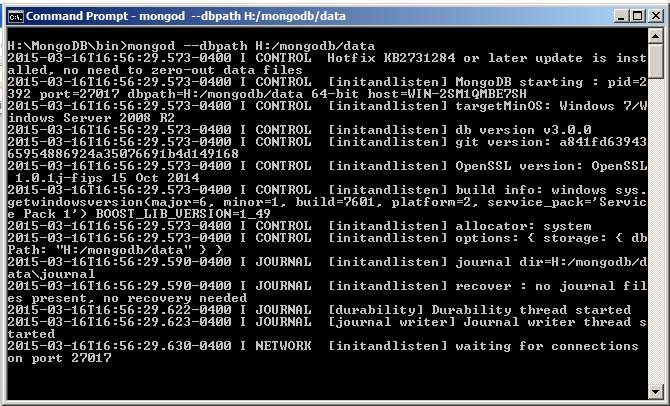


### Evidence 2
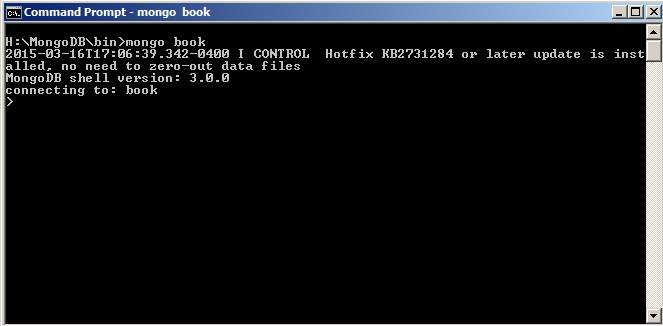


What does the mongo book statement do?


The book database is initialized and connected to.


### Evidence 3
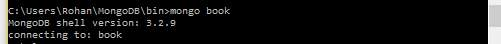


-----------------------------------------------------------------------------------


Now let's explore some of the features and functions of MongoDB. From now on, when you enter any commands they will be in the mongo client terminal.


In your mongo client terminal enter: help<return>


Place a screenshot of your terminal below:


### Evidence 4
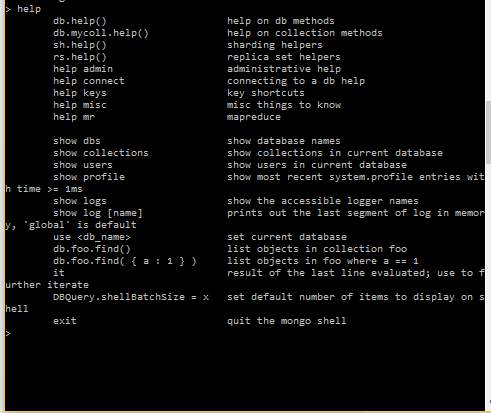


Now enter: show dbs<return>


How many Databases do you see?  What is it's name?


### Evidence 5
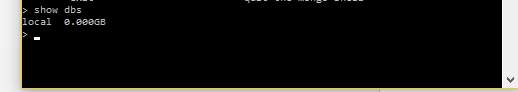


I see a  Local database which has zero gb size.


Now enter the following:  db.towns.insert({ name: "New York", population: 2220000, last_census: ISODate(


"2009-07-31"), famous_for: [ "statue of liberty","food"],


mayor: { name: "Michael Bloomberg", party: "I" } })<return>


### Evidence 6
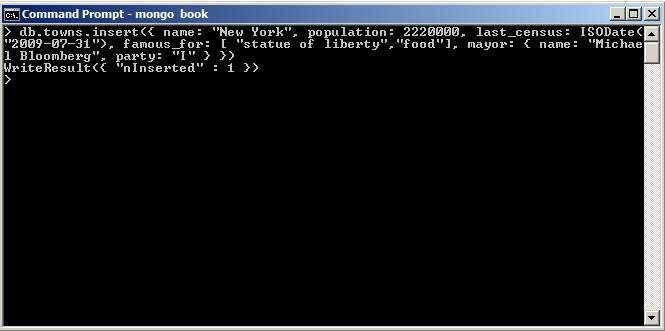


You should see the above result.  Now enter: show dbs<return> again.


Place a screen shot of your terminal below:


### Evidence 7
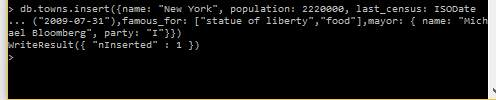


### Evidence 8
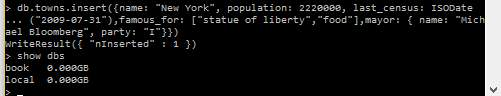


Why did we not see this result before?


Because we did not have any collections data in the database. After we inserted data into the


books collection we got the books database returned.


Enter: help<return>


You see a list of commands that you can use from the command line.


Try entering: show collections<return>


What collections do you see?


I see a towns collection.


### Evidence 9
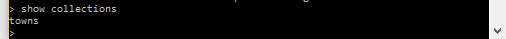


-----------------------------------------------------------------------------------


Let's continue our exploration.


Enter: help admin<return>


Now look at the list and enter the first command:ls<return>


Now try: ls()


Paste a screenshot of your results below:


### Evidence 10
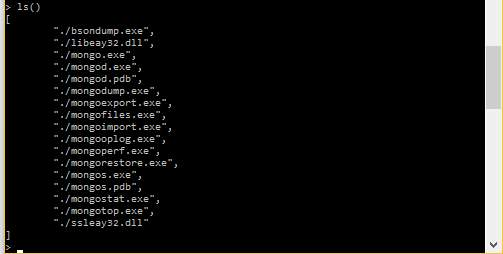


Try: listfiles()<return>


What happens?


I get an error saying that listfiles is not defined.


### Evidence 11
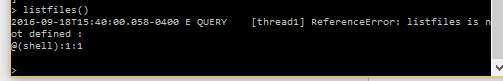


Now try: listFiles()<return>


Paste a Screenshot below of your results:


### Evidence 12
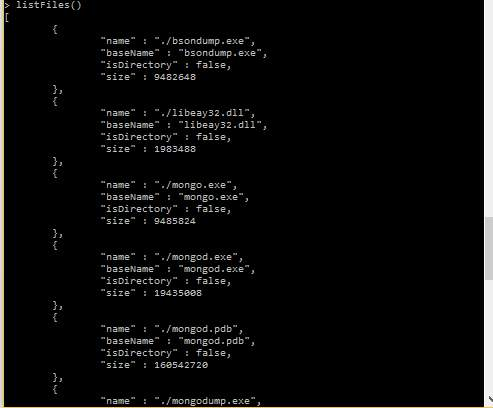


-----------------------------------------------------------------------------------


Let's list your collection.


Enter: db.towns.find()<return>


Paste a screenshot of your results below:


### Evidence 13
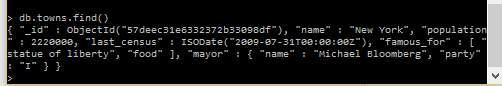


### Evidence 14
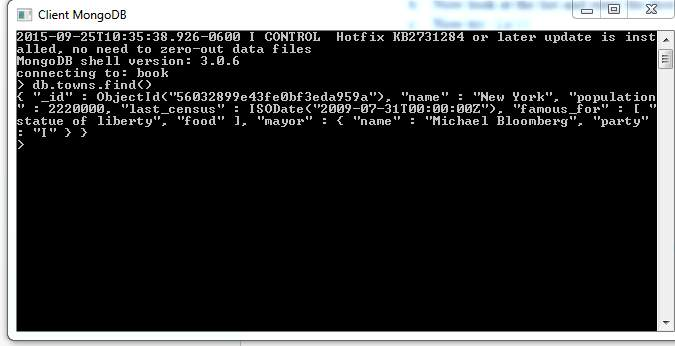


------------------------------------------------------------------------------


PART II: Working with data in MongoDB


-----------------------------------------------------------------------------------


Hopefully you have your Seven Weeks book open.  Let's go to page 139.  Read this page and go ahead and checkout how MongoDB returns the various results found on this page when you query the typeof db and collection and the typeof db.towns.insert objects.


Go ahead and enter: db.towns.insert<return>


### Evidence 15
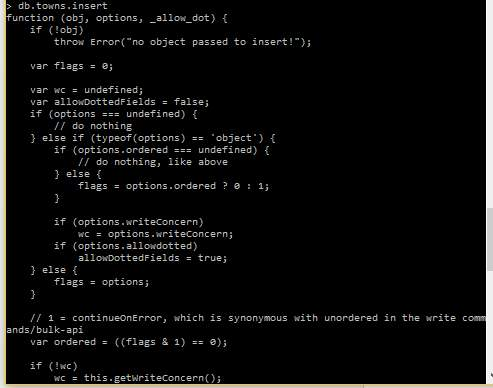


Now let's turn the page and enter the InsertCity function:


function insertCity(


name, population, last_census,


famous_for, mayor_info


) {


In [ ]:
db.towns.insert({


name:name,


population:population,


last_census: ISODate(last_census),


famous_for:famous_for,


mayor: mayor_info});


}


<return>


What did you really just do above?


I defined a function that takes in properties data for a city/town.


Go ahead and enter the two additional cities found on page 140 into the database.


Verify their existence:db.towns.find()<return>


Paste a screenshot of your results below:


### Evidence 16
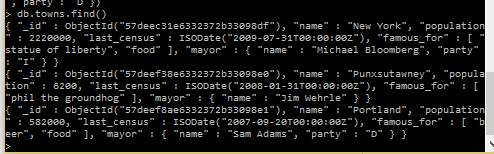


-----------------------------------------------------------------------------------


Now let's look at some queries:


Enter: db.towns.find({population:  {$lt:10000}})


Paste a screenshot of your results below:


### Evidence 17
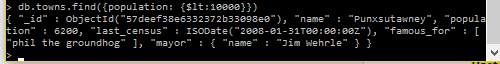


Now try limiting your results:  db.towns.find({population: {$lt:10000}},{name: 1, population:1})


What happened this time?


I got town name as Punxsutawyney with population of 6200.


### Evidence 18
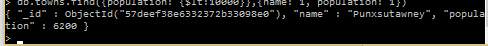


Let's try the range query.  Enter the following:


var population_range = {}


population_range['$lt']=1000000


population_range['$gt']=10000


In [ ]:
db.towns.find(


{ population : population_range},


{name : 1})


Paste a screenshot of your results below:


### Evidence 19
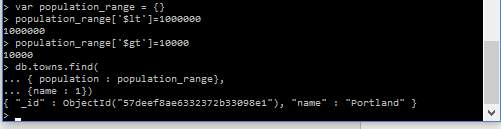


Now you try it.  Develop a query that will find all towns with the string 'and' in their name.


Paste your results below:


### Evidence 20
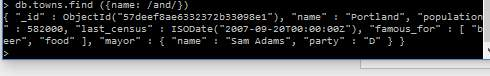


-----------------------------------------------------------------------------------


On page 143 of the Seven Weeks text, we see how to override the _id field with a value of our own.  Insert the three countries and two of your own so you have five altogether into your MongoDB database.


Here is the first one: db.countries.insert({


_id: "us",


name : "United States",


exports : {


foods : [


{name : "bacon", tasty : true},


{name: "burgers"}


]


}


})


### Evidence 21
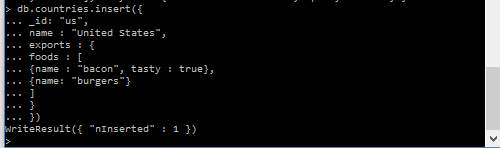


In [ ]:
db.countries.insert({


_id : “ca”,


name : “Canada”,


exports : {


foods: [


{ name : “bacon”, tasty : false},


{ name : “syrup”, tasty : true}


]


}


})


In [ ]:
db.countries.insert({


_id : “mx”,


name : “Mexico”,


exports : {


foods: [{


name : “salsa”,


tasty : true,


condiment : true


}]


}


})


In [ ]:
db.countries.insert({


_id : “ind”,


name : “India”,


exports : {


foods: [{


name : “samosa”,


tasty : true,


snack: true


}]


}


})


In [ ]:
db.countries.insert({


_id : “esp”,


name : “Spain”,


exports : {


foods: [{


name : “burrito”,


tasty : true,


snack: true


}]


}


})


Now execute: show collections<return>


### Evidence 22
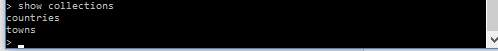


Notice you've created a new collection?  Now enter the remaining four countries on your own.


Execute a db.countries.find() statement and post a screenshot of your results below.


### Evidence 23
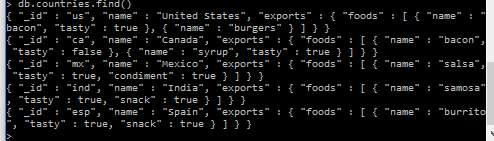


---------------------------------------------------------------------------------------------------------


Now let's look at what we did:


Enter: print (db.countries.count() ) <return>


### Evidence 24
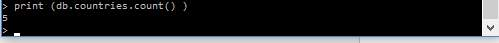


Now try: db.countries.find(


{ 'exports.foods.name' : 'bacon','export.foods.tasty' : true},


{_id: 0, name: 1}


)


Paste a screenshot of your results below:


Should return USA


### Evidence 25
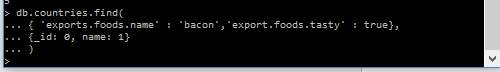


-----------------------------------------------------------------------------------


Part III - Exploring different MongoDB Data Model Patterns


-----------------------------------------------------------------------------------


Using the following diagram let's take a look a couple of ways to model this in the MongoDB database.  First let's look at the Parent Reference Pattern.


### Evidence 26
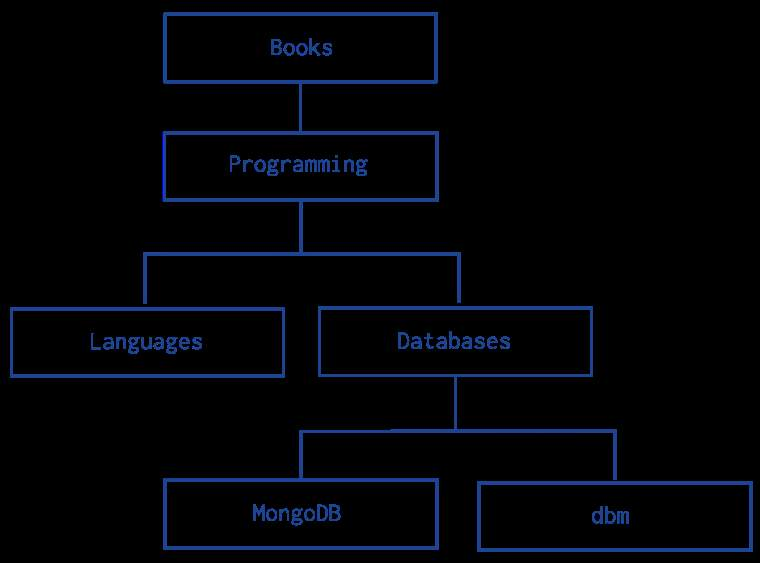


Figure  - Sample Data Model of Hierarchies - http://docs.mongodb.org/manual/tutorial/model-tree-structures-with-parent-references/


Let's create the database:


In [ ]:
db.categories.insert( { _id: "MongoDB", parent: "Databases" } )


In [ ]:
db.categories.insert( { _id: "dbm", parent: "Databases" } )


In [ ]:
db.categories.insert( { _id: "Databases", parent: "Programming" } )


In [ ]:
db.categories.insert( { _id: "Languages", parent: "Programming" } )


In [ ]:
db.categories.insert( { _id: "Programming", parent: "Books" } )


In [ ]:
db.categories.insert( { _id: "Books", parent: null } )


Display all documents in the categories collection.\


Post a screenshot of your results below:


### Evidence 27
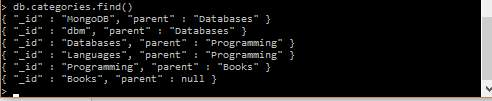


-----------------------------------------------------------------------------------


Find the MongoDB document parent:


Enter: db.categories.findOne( { _id: "MongoDB" } ).parent


### Evidence 28
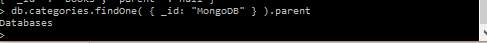


Find the parent of the dbm document.


In [ ]:
db.categories.findOne( { _id: "dbm" } ).parent


### Evidence 29



Now find the parent of the Languages document.


In [ ]:
db.categories.findOne( { _id: "Languages" } ).parent


### Evidence 30
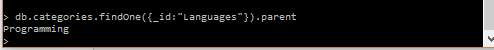


-----------------------------------------------------------------------------------


Now try to write a query to find the children of the Databases document:


In [ ]:
db.categories.findOne( { _id: "Databases" } ).child


Past screenshot of your results below:


As you can see, you can find parents or children fairly simply.


### Evidence 31
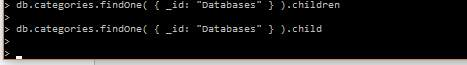


-----------------------------------------------------------------------------------


Now let's look at the reverse type of pattern, where we insert child references:


First, let's clean up our collections: db.categories.drop()<return>


Now let's add the same data using the child pattern:


In [ ]:
db.categories.insert( { _id: "MongoDB", children: [] } )


In [ ]:
db.categories.insert( { _id: "dbm", children: [] } )


In [ ]:
db.categories.insert( { _id: "Databases", children: [ "MongoDB", "dbm" ] } )


In [ ]:
db.categories.insert( { _id: "Languages", children: [] } )


In [ ]:
db.categories.insert( { _id: "Programming", children: [ "Databases", "Languages" ] } )


In [ ]:
db.categories.insert( { _id: "Books", children: [ "Programming" ] } )


### Evidence 32
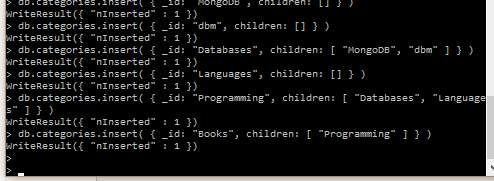


Notice the difference between the parent and child patterns?


What does the empty [ ] mean?


The empty []  means that the node references the children nodes of its parent elements as its children.


-----------------------------------------------------------------------------------


a. What is the child of the Databases node:


In [ ]:
db.categories.findOne( { _id: "Databases" } ).children


Paste a screenshot of your results below:


### Evidence 33
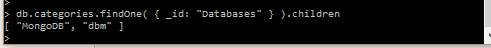


b. Now enter: db.categories.find( { children: "MongoDB" } )


What happens?


I get MongoDB and dbm as children of MongoDB.


### Evidence 34
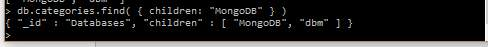


-----------------------------------------------------------------------------------


## Modernization Notes

This notebook preserves the historical lab sequence. Before rerunning, validate versions, package repositories, service commands, client shells, and platform-specific paths against current vendor documentation.
